# Stock Market Activity & News Sentiment — Findings Analysis

## tl;dr

1. **The latest observed market session was broadly weak.** On 2026-08-28,
   **27.1%** of securities advanced and median open-to-close return was
   **-0.43%**.
2. **Trading activity was highly concentrated.** Technology produced **39.1%**
   of estimated trading value from **11.3%** of observed securities, while its
   median return was **-1.32%**. The top 1% of securities generated **52.3%** of
   estimated trading value.
3. **News sentiment is context, not a directional signal.** Same-day ticker
   sentiment and return had only **0.069 Pearson correlation** after the stated
   liquidity/price filter, while company-news coverage varied materially by day.

These findings describe the committed local warehouse snapshot. Rerun the
notebook and refresh this summary after loading additional dates.


## Context & Methods

### Decision frame

The analysis defines the metric hierarchy for the portfolio dashboard: market
breadth first, activity concentration second, sector participation third, and
news sentiment as supporting context.

### Key assumptions and limitations

- Source of truth: local DuckDB warehouse `database/config_dwh/mydb.duckdb`.
- The observed date range is derived from the warehouse at execution time.
- Data-collection gaps reflect when the project was not operating; they are not
  treated as market events or analytical findings.
- `return_pct` is same-session open-to-close return, not total return or
  close-to-close return.
- `estimated_trading_value = volume × volume_weighted`; it is an activity proxy,
  not revenue or market capitalization.
- Median return and advancer share are the headline market measures because the
  arithmetic mean is sensitive to penny/OTC outliers.
- Sentiment/return comparisons are observational and same-day only; they do not
  establish prediction or causality.


## Data

### 1. Connect to the warehouse

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

project_root = Path.cwd()
if not (project_root / "database").exists():
    project_root = project_root.parent

database_path = project_root / "database" / "config_dwh" / "mydb.duckdb"
assert database_path.exists(), f"DuckDB not found: {database_path}"

connection = duckdb.connect(str(database_path), read_only=True)
print(f"Warehouse: {database_path.relative_to(project_root)}")

Warehouse: database\config_dwh\mydb.duckdb


### 2. Confirm coverage and grain

In [2]:
coverage = connection.execute(
    """
    SELECT
        t.date,
        COUNT(*) AS candles,
        COUNT(DISTINCT f.company_id) AS companies,
        SUM(f.volume) AS volume,
        SUM(f.num_of_trades) AS trades
    FROM fact_candles AS f
    JOIN dim_time AS t ON t.id = f.time_id
    GROUP BY t.date
    ORDER BY t.date
    """
).fetchdf()
coverage

,date,candles,companies,volume,trades
0,2026-08-20,7830,7830,1.286343e+10,108375296.0
1,2026-08-25,7869,7869,1.198315e+10,97107157.0
2,2026-08-26,7832,7832,1.035184e+10,95506965.0
3,2026-08-27,7854,7854,1.214971e+10,102141711.0
4,2026-08-28,7806,7806,1.317791e+10,98622786.0


In [3]:
grain_checks = connection.execute(
    """
    SELECT
        (SELECT COUNT(*) - COUNT(DISTINCT date) FROM dim_time) AS duplicate_dates,
        (SELECT COUNT(*) - COUNT(DISTINCT (ticker, is_delisted)) FROM dim_companies) AS duplicate_company_snapshots,
        (SELECT COUNT(*) - COUNT(DISTINCT url) FROM dim_news) AS duplicate_news_urls,
        (SELECT COUNT(*) - COUNT(DISTINCT (company_id, time_id)) FROM fact_candles) AS duplicate_candles,
        (SELECT COUNT(*) - COUNT(DISTINCT (new_id, company_id)) FROM fact_news_companies) AS duplicate_news_company_links,
        (SELECT COUNT(*) - COUNT(DISTINCT (new_id, topic_id)) FROM fact_news_topics) AS duplicate_news_topic_links
    """
).fetchdf()
assert grain_checks.iloc[0].sum() == 0
grain_checks

,duplicate_dates,duplicate_company_snapshots,duplicate_news_urls,duplicate_candles,duplicate_news_company_links,duplicate_news_topic_links
0,0,0,0,0,0,0


## Results

### 3. Market breadth and median return by observed session

In [4]:
daily_market = connection.execute(
    """
    WITH security_day AS (
        SELECT
            t.date,
            100.0 * (f.close / f.open - 1) AS return_pct,
            f.volume,
            f.volume_weighted,
            f.num_of_trades
        FROM fact_candles AS f
        JOIN dim_time AS t ON t.id = f.time_id
        WHERE f.open > 0
    )
    SELECT
        date,
        COUNT(*) AS securities,
        ROUND(AVG(return_pct), 2) AS mean_return_pct,
        ROUND(MEDIAN(return_pct), 2) AS median_return_pct,
        ROUND(100.0 * AVG((return_pct > 0)::INTEGER), 1) AS advancers_pct,
        ROUND(QUANTILE_CONT(return_pct, 0.10), 2) AS p10_return_pct,
        ROUND(QUANTILE_CONT(return_pct, 0.90), 2) AS p90_return_pct,
        ROUND(SUM(volume * volume_weighted) / 1e9, 2) AS estimated_trading_value_bn,
        ROUND(SUM(num_of_trades) / 1e6, 2) AS trades_mn
    FROM security_day
    GROUP BY date
    ORDER BY date
    """
).fetchdf()
daily_market

,date,securities,mean_return_pct,median_return_pct,advancers_pct,p10_return_pct,p90_return_pct,estimated_trading_value_bn,trades_mn
0,2026-08-20,7830,1.47,-0.08,39.1,-3.40,2.29,739.20,108.38
1,2026-08-25,7869,2.16,0.00,50.0,-2.25,3.33,635.80,97.11
2,2026-08-26,7832,1.81,0.00,43.1,-2.61,2.50,645.08,95.51
3,2026-08-27,7854,1.57,0.00,47.4,-2.57,2.84,765.96,102.14
4,2026-08-28,7806,-0.61,-0.43,27.1,-4.41,1.46,693.79,98.62


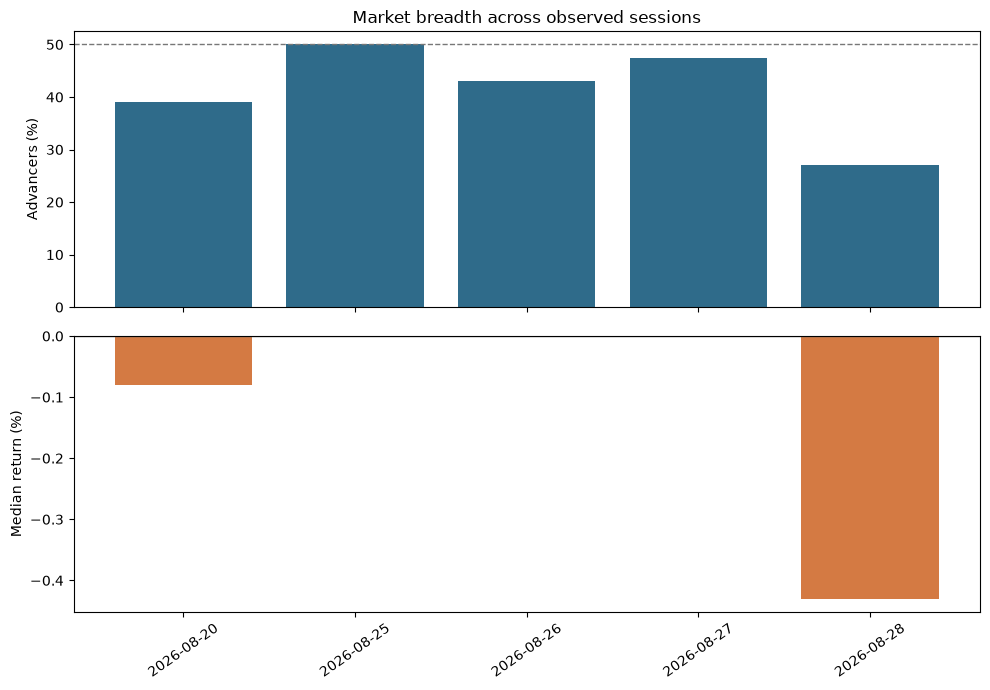

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].bar(daily_market["date"].astype(str), daily_market["advancers_pct"], color="#2f6b8a")
axes[0].axhline(50, color="#777777", linewidth=1, linestyle="--")
axes[0].set_ylabel("Advancers (%)")
axes[0].set_title("Market breadth across observed sessions")

axes[1].bar(daily_market["date"].astype(str), daily_market["median_return_pct"], color="#d47a43")
axes[1].axhline(0, color="#777777", linewidth=1)
axes[1].set_ylabel("Median return (%)")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

### 4. Inspect return outliers before interpreting the mean

In [6]:
largest_return_outliers = connection.execute(
    """
    WITH security_day AS (
        SELECT
            t.date,
            c.ticker,
            c.name,
            f.open,
            f.close,
            f.volume,
            100.0 * (f.close / f.open - 1) AS return_pct
        FROM fact_candles AS f
        JOIN dim_time AS t ON t.id = f.time_id
        JOIN dim_companies AS c ON c.id = f.company_id
        WHERE f.open > 0
    )
    SELECT *
    FROM security_day
    QUALIFY ROW_NUMBER() OVER (PARTITION BY date ORDER BY ABS(return_pct) DESC) = 1
    ORDER BY date
    """
).fetchdf()
largest_return_outliers

,date,ticker,name,open,close,volume,return_pct
0,2026-08-20,BTTX,BETTER THERAPEUTICS INC,0.000001,0.0001,822,9900.0
1,2026-08-25,HBRM,HERBORIUM,0.000001,0.0001,3613000,9900.0
2,2026-08-26,FUVV,ARCIMOTO INC,0.000001,0.0001,2024,9900.0
3,2026-08-27,BIGGQ,BIG LOTS INC,0.000001,0.0001,9099,9900.0
4,2026-08-28,OPTI,OPTI INC,0.000200,0.0018,177918,800.0


### 5. Latest market session: sector participation and activity

In [7]:
latest_sector = connection.execute(
    """
    WITH security_day AS (
        SELECT
            COALESCE(NULLIF(TRIM(c.sector), ''), 'Unknown') AS sector,
            100.0 * (f.close / f.open - 1) AS return_pct,
            f.volume * f.volume_weighted AS estimated_trading_value
        FROM fact_candles AS f
        JOIN dim_time AS t ON t.id = f.time_id
        JOIN dim_companies AS c ON c.id = f.company_id
        WHERE t.date = (
            SELECT MAX(t2.date)
            FROM fact_candles AS f2
            JOIN dim_time AS t2 ON t2.id = f2.time_id
        ) AND f.open > 0
    ), sector_summary AS (
        SELECT
            sector,
            COUNT(*) AS securities,
            MEDIAN(return_pct) AS median_return_pct,
            100.0 * AVG((return_pct > 0)::INTEGER) AS advancers_pct,
            SUM(estimated_trading_value) AS estimated_trading_value
        FROM security_day
        GROUP BY sector
    )
    SELECT
        sector,
        securities,
        ROUND(100.0 * securities / SUM(securities) OVER (), 1) AS securities_share_pct,
        ROUND(median_return_pct, 2) AS median_return_pct,
        ROUND(advancers_pct, 1) AS advancers_pct,
        ROUND(estimated_trading_value / 1e9, 1) AS estimated_trading_value_bn,
        ROUND(100.0 * estimated_trading_value / SUM(estimated_trading_value) OVER (), 1) AS trading_value_share_pct
    FROM sector_summary
    ORDER BY estimated_trading_value DESC
    """
).fetchdf()
latest_sector

,sector,securities,securities_share_pct,median_return_pct,advancers_pct,estimated_trading_value_bn,trading_value_share_pct
0,Technology,880,11.3,-1.32,28.1,271.4,39.1
1,Unknown,1586,20.3,-0.30,18.6,68.5,9.9
2,Financial Services,1094,14.0,-0.19,33.7,61.2,8.8
3,Consumer Cyclical,562,7.2,-0.36,35.9,60.3,8.7
4,Industrials,1040,13.3,-0.45,23.9,57.4,8.3
5,Healthcare,1155,14.8,-1.36,22.9,48.6,7.0
6,Communication Services,293,3.8,0.00,46.4,42.2,6.1
7,Basic Materials,291,3.7,-1.54,16.8,23.5,3.4
8,Energy,236,3.0,-0.33,37.7,18.7,2.7
9,Consumer Defensive,277,3.5,0.00,45.8,18.7,2.7


In [8]:
latest_concentration = connection.execute(
    """
    WITH security_activity AS (
        SELECT f.volume * f.volume_weighted AS estimated_trading_value
        FROM fact_candles AS f
        JOIN dim_time AS t ON t.id = f.time_id
        WHERE t.date = (
            SELECT MAX(t2.date)
            FROM fact_candles AS f2
            JOIN dim_time AS t2 ON t2.id = f2.time_id
        )
    ), ranked AS (
        SELECT
            estimated_trading_value,
            ROW_NUMBER() OVER (ORDER BY estimated_trading_value DESC) AS rank,
            COUNT(*) OVER () AS security_count,
            SUM(estimated_trading_value) OVER () AS total_volume
        FROM security_activity
    )
    SELECT
        ROUND(100.0 * SUM(CASE WHEN rank <= 10 THEN estimated_trading_value ELSE 0 END) / MAX(total_volume), 1) AS top_10_share_pct,
        ROUND(100.0 * SUM(CASE WHEN rank <= CEIL(security_count * 0.01) THEN estimated_trading_value ELSE 0 END) / MAX(total_volume), 1) AS top_1pct_share_pct
    FROM ranked
    """
).fetchdf()
latest_concentration

,top_10_share_pct,top_1pct_share_pct
0,25.0,52.3


### 6. News sentiment alongside same-day market breadth

In [9]:
daily_news = connection.execute(
    """
    WITH news_summary AS (
        SELECT
            n.time_id,
            COUNT(*) AS news,
            100.0 * AVG((n.overall_sentiment_label IN ('Bullish', 'Somewhat-Bullish'))::INTEGER) AS bullish_news_pct,
            100.0 * AVG((n.overall_sentiment_label IN ('Bearish', 'Somewhat-Bearish'))::INTEGER) AS bearish_news_pct
        FROM dim_news AS n
        GROUP BY n.time_id
    ), company_coverage AS (
        SELECT n.time_id, COUNT(DISTINCT f.company_id) AS news_companies
        FROM fact_news_companies AS f
        JOIN dim_news AS n ON n.id = f.new_id
        GROUP BY n.time_id
    ), candle_coverage AS (
        SELECT time_id, COUNT(DISTINCT company_id) AS candle_companies
        FROM fact_candles
        GROUP BY time_id
    )
    SELECT
        t.date,
        n.news,
        ROUND(n.bullish_news_pct, 1) AS bullish_news_pct,
        ROUND(n.bearish_news_pct, 1) AS bearish_news_pct,
        c.candle_companies,
        COALESCE(k.news_companies, 0) AS news_companies,
        ROUND(100.0 * COALESCE(k.news_companies, 0) / c.candle_companies, 1) AS company_news_coverage_pct
    FROM news_summary AS n
    JOIN dim_time AS t ON t.id = n.time_id
    JOIN candle_coverage AS c ON c.time_id = n.time_id
    LEFT JOIN company_coverage AS k ON k.time_id = n.time_id
    ORDER BY t.date
    """
).fetchdf()
daily_news

,date,news,bullish_news_pct,bearish_news_pct,candle_companies,news_companies,company_news_coverage_pct
0,2026-08-20,7576,49.9,15.8,7830,2493,31.8
1,2026-08-25,5876,52.8,14.6,7869,2072,26.3
2,2026-08-26,2318,59.0,10.3,7832,990,12.6
3,2026-08-27,538,57.8,16.2,7854,306,3.9
4,2026-08-28,244,66.0,13.1,7806,146,1.9


In [10]:
sentiment_vs_market = daily_news.merge(
    daily_market[["date", "advancers_pct", "median_return_pct"]], on="date", how="inner"
)
sentiment_vs_market

,date,news,bullish_news_pct,bearish_news_pct,candle_companies,news_companies,company_news_coverage_pct,advancers_pct,median_return_pct
0,2026-08-20,7576,49.9,15.8,7830,2493,31.8,39.1,-0.08
1,2026-08-25,5876,52.8,14.6,7869,2072,26.3,50.0,0.00
2,2026-08-26,2318,59.0,10.3,7832,990,12.6,43.1,0.00
3,2026-08-27,538,57.8,16.2,7854,306,3.9,47.4,0.00
4,2026-08-28,244,66.0,13.1,7806,146,1.9,27.1,-0.43


### 7. Same-day ticker sentiment and return association

In [11]:
sentiment_quintiles = connection.execute(
    """
    WITH company_sentiment AS (
        SELECT
            n.time_id,
            f.company_id,
            AVG(f.ticker_sentiment_score) AS sentiment_score,
            COUNT(*) AS article_count
        FROM fact_news_companies AS f
        JOIN dim_news AS n ON n.id = f.new_id
        GROUP BY n.time_id, f.company_id
    ), company_day AS (
        SELECT
            s.*,
            100.0 * (f.close / f.open - 1) AS return_pct,
            f.open,
            f.volume
        FROM company_sentiment AS s
        JOIN fact_candles AS f
          ON f.time_id = s.time_id AND f.company_id = s.company_id
        WHERE f.open > 0
    ), ranked AS (
        SELECT *, NTILE(5) OVER (ORDER BY sentiment_score) AS sentiment_quintile
        FROM company_day
    )
    SELECT
        sentiment_quintile,
        COUNT(*) AS company_days,
        ROUND(AVG(sentiment_score), 3) AS avg_sentiment_score,
        ROUND(MEDIAN(return_pct), 2) AS median_return_pct,
        ROUND(100.0 * AVG((return_pct > 0)::INTEGER), 1) AS advancers_pct
    FROM ranked
    GROUP BY sentiment_quintile
    ORDER BY sentiment_quintile
    """
).fetchdf()

filtered_sentiment_correlation = connection.execute(
    """
    WITH company_sentiment AS (
        SELECT n.time_id, f.company_id, AVG(f.ticker_sentiment_score) AS sentiment_score
        FROM fact_news_companies AS f
        JOIN dim_news AS n ON n.id = f.new_id
        GROUP BY n.time_id, f.company_id
    )
    SELECT
        COUNT(*) AS company_days,
        ROUND(CORR(s.sentiment_score, 100.0 * (f.close / f.open - 1)), 3) AS pearson_correlation
    FROM company_sentiment AS s
    JOIN fact_candles AS f
      ON f.time_id = s.time_id AND f.company_id = s.company_id
    WHERE f.open >= 1 AND f.volume >= 100000
    """
).fetchdf()

display(sentiment_quintiles)
display(filtered_sentiment_correlation)

,sentiment_quintile,company_days,avg_sentiment_score,median_return_pct,advancers_pct
0,1,1181,-0.234,-0.51,38.3
1,2,1181,0.047,-0.10,44.4
2,3,1181,0.166,-0.17,43.9
3,4,1181,0.290,0.00,49.9
4,5,1181,0.459,-0.03,48.7


,company_days,pearson_correlation
0,5173,0.069


### 8. Classification coverage for sector-level interpretation

In [12]:
classification_coverage = connection.execute(
    """
    SELECT
        t.date,
        COUNT(*) AS candle_rows,
        SUM((NULLIF(TRIM(c.sector), '') IS NULL)::INTEGER) AS blank_sector_rows,
        ROUND(100.0 * SUM((NULLIF(TRIM(c.sector), '') IS NULL)::INTEGER) / COUNT(*), 1) AS blank_sector_pct,
        SUM((NULLIF(TRIM(c.industry), '') IS NULL)::INTEGER) AS blank_industry_rows,
        ROUND(100.0 * SUM((NULLIF(TRIM(c.industry), '') IS NULL)::INTEGER) / COUNT(*), 1) AS blank_industry_pct
    FROM fact_candles AS f
    JOIN dim_time AS t ON t.id = f.time_id
    JOIN dim_companies AS c ON c.id = f.company_id
    GROUP BY t.date
    ORDER BY t.date
    """
).fetchdf()
classification_coverage

,date,candle_rows,blank_sector_rows,blank_sector_pct,blank_industry_rows,blank_industry_pct
0,2026-08-20,7830,1602.0,20.5,1602.0,20.5
1,2026-08-25,7869,1615.0,20.5,1615.0,20.5
2,2026-08-26,7832,1613.0,20.6,1613.0,20.6
3,2026-08-27,7854,1609.0,20.5,1609.0,20.5
4,2026-08-28,7806,1586.0,20.3,1586.0,20.3


## Takeaways

### Key findings

1. The latest market session combined weak breadth (**27.1% advancers**) with a
   negative median return (**-0.43%**); the mean was not used as the headline
   because extreme low-price securities produced implausibly large percentage
   returns.
2. Technology accounted for **39.1% of estimated trading value** but **11.3% of
   securities**, and its median return was **-1.32%**. High activity therefore
   did not imply broad positive performance.
3. Estimated trading value was concentrated: the top 1% of securities generated
   **52.3%** of the latest observed total.
4. Same-day ticker sentiment and return had **0.069 Pearson correlation** after
   filtering to price at least $1 and volume at least 100,000. This is weak
   association, not evidence that news predicts price movement.
5. `Unknown` represented **20.3%** of the latest sector classification, so it
   must remain visible in sector views rather than being silently excluded.

### Dashboard implications

- Read advancer share together with median open-to-close return; either metric
  alone gives an incomplete view of market breadth.
- Use estimated trading value to describe observed activity, not company value,
  revenue, assets, or market capitalization.
- Compare sector activity share with sector breadth and return so that a large
  sector is not automatically described as a strong sector.
- Treat news sentiment as context. Same-day association is observational and is
  not evidence of prediction or causality.
- Show company-news coverage next to sentiment because coverage changed from
  **31.8% to 1.9%** across observed market sessions.
- Keep `Unknown` visible in classification views and show its coverage impact
  rather than silently dropping those rows.

### Evidence boundary

The outputs describe only sessions present in the local warehouse. They are not
claims about the full US equity market, long-term performance, causal effects of
news, or a tradable strategy.


In [13]:
connection.close()
print('Analysis complete.')

Analysis complete.
